# Soccer Goal Prediction with Expected Goals (xG)

## Project Overview
This project builds a machine learning model to predict the probability 
that a soccer shot will result in a goal, using event data from StatsBomb. 
The model accounts for shot location, angle, body part, and game context 
to generate Expected Goals (xG) values.

## Key Challenge
Real soccer data is heavily imbalanced (only ~11% of shots are goals), 
which requires careful handling through class weighting to produce 
calibrated probability estimates.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from  sklearn.ensemble import  RandomForestClassifier
from sklearn.calibration import CalibrationDisplay
from scipy.stats import poisson_binom
import scipy,sklearn

The data contains shot location (x,y coordinates), shot type, body part used, and whether it resulted in a goal. I'll one-hot encode categorical features and standardize numeric features.

## Process Data

In [3]:
input_df=pd.read_csv('xg_train.csv')
input_y=input_df['is_goal']
input_df=input_df.drop(columns=['is_goal'])
string_cols = input_df.select_dtypes(include=["object", "string"]).columns
numeric_cols = input_df.select_dtypes(include=["number"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), string_cols),
        ("num", StandardScaler(), numeric_cols)],    
        verbose_feature_names_out=False,
        remainder="drop",
        sparse_threshold=0,
)

X_processed = preprocess.fit_transform(input_df)
df_processed = pd.DataFrame(X_processed, columns=list(preprocess.get_feature_names_out()))

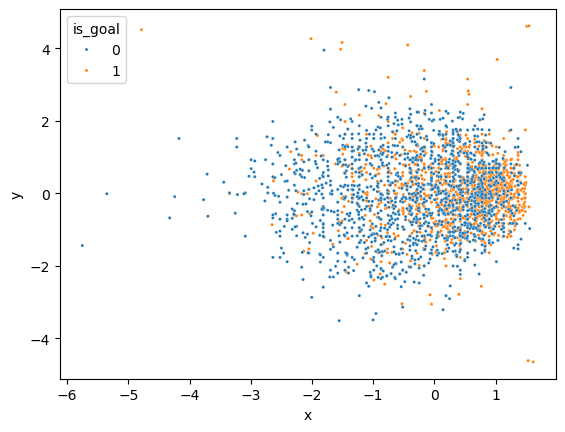

In [5]:
import seaborn as sns
sns.scatterplot(df_processed,x='x',y='y',hue=input_y, s = 5)
plt.show()

## Split Data

In [9]:
X = X_processed
y = input_y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

I'll train a Random Forest classifier with class weights adjusted to match real-world goal rates (11.3%), ensuring the model's probability estimates are calibrated.

## Train Model and Evaluate with ECE

In [10]:
hyper_parameters={
    'max_depth': 5,
    'min_samples_leaf': 50,
    'n_estimators': 500,
    'max_features': 0.5
}

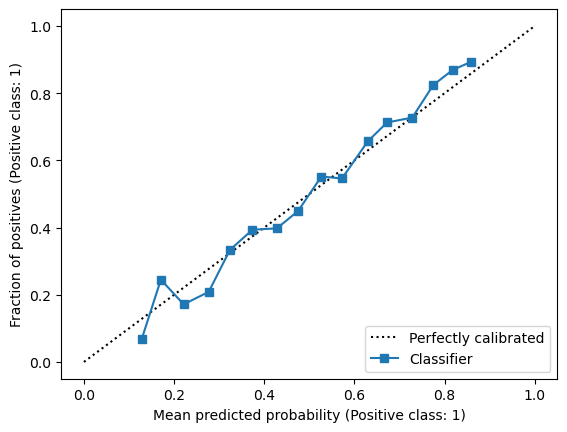

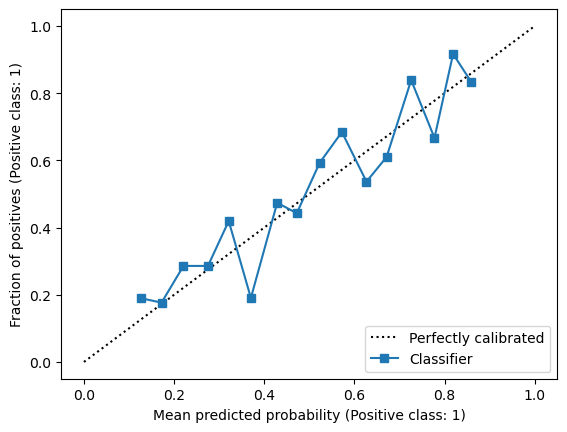

In [19]:
model = RandomForestClassifier(**hyper_parameters)
model.fit(X_train, y_train)
train_probs = model.predict_proba(X_train)
test_probs = model.predict_proba(X_test)


CalibrationDisplay.from_predictions(y_train, train_probs[:,1], n_bins = 20)
CalibrationDisplay.from_predictions(y_test, test_probs[:,1], n_bins = 20)

Test set shows that our data is callibrated decently well. We underestimate the amount of goals at 0.6, but overestimate at 0.65 and 0.7. 

The calibration plot shows the model is well-calibrated with deviations under 5%, meaning the predicted probabilities closely match actual outcomes.

In [17]:
train_acc = (y_train==(train_probs[:,1]>0.5)).mean()
test_acc = (y_test==(test_probs[:,1]>0.5)).mean()


In [20]:
# Caculate ece
def ece(y_true, y_prob):
    n_bins=10
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    assert y_prob.ndim == 1
    conf = y_prob    
    bins = np.linspace(0, 1, n_bins+1)
    b = np.digitize(conf, bins) - 1
    e = 0.
    for i in range(n_bins):
        m = b == i
        if m.any():
            e += m.mean() * abs(y_true[m].mean() - conf[m].mean())
    return e

In [22]:
train_ece=ece(y_train,train_probs[:,1])
test_ece=ece(y_test,test_probs[:,1])

print(f"Train Accuracy {train_acc} Test Accuracy {test_acc}")
print(f"Train ECE {train_ece} Test {test_ece}")

Train Accuracy 0.701808557565064 Test Accuracy 0.6931216931216931
Train ECE 0.029628416426776643 Test 0.04901957745697054


## Apply Model to a Test Game

In [23]:
test_game=pd.read_csv('test_game.csv')
display(test_game)

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id
0,9154,7477,Portland Thorns,Tobin Powell Heath,1,0,103.0,36.0,17.464249,0.231091,Right Foot,Normal,Regular Play,1,49,3
1,9155,7477,Portland Thorns,Tobin Powell Heath,4,4,105.0,51.0,18.601075,0.632749,Left Foot,Half Volley,From Throw In,0,49,3
2,9156,7477,Utah Royals,Diana Matheson,9,24,103.0,33.0,18.384776,0.390607,Right Foot,Normal,From Throw In,0,49,3
3,9157,7477,Portland Thorns,Tobin Powell Heath,23,56,90.0,29.0,31.953091,0.351445,Right Foot,Normal,From Throw In,0,49,3
4,9158,7477,Portland Thorns,Hayley Emma Raso,27,42,94.0,36.0,26.305893,0.152649,Right Foot,Normal,Regular Play,0,49,3
5,9159,7477,Portland Thorns,Lindsey Michelle Horan,31,27,112.0,41.0,8.062258,0.124355,Head,Normal,From Free Kick,1,49,3
6,9160,7477,Portland Thorns,Ana-Maria Crnogorčević,33,21,107.0,47.0,14.764823,0.493941,Left Foot,Normal,From Counter,1,49,3
7,9161,7477,Portland Thorns,Hayley Emma Raso,45,10,107.0,45.0,13.928388,0.367174,Head,Normal,Regular Play,0,49,3
8,9162,7477,Utah Royals,Katrina Gorry,52,48,94.0,31.0,27.513633,0.333244,Left Foot,Normal,Regular Play,0,49,3
9,9163,7477,Portland Thorns,Ellie Madison Carpenter,55,25,89.0,66.0,40.459857,0.697903,Right Foot,Normal,Regular Play,0,49,3


In [24]:
test_game_X = test_game.drop(columns=['is_goal'])

X_test_game_processed = preprocess.transform(test_game_X)

probs = model.predict_proba(X_test_game_processed)[:,1]

test_game['xG'] = probs

display(test_game) 

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id,xG
0,9154,7477,Portland Thorns,Tobin Powell Heath,1,0,103.0,36.0,17.464249,0.231091,Right Foot,Normal,Regular Play,1,49,3,0.441269
1,9155,7477,Portland Thorns,Tobin Powell Heath,4,4,105.0,51.0,18.601075,0.632749,Left Foot,Half Volley,From Throw In,0,49,3,0.388126
2,9156,7477,Utah Royals,Diana Matheson,9,24,103.0,33.0,18.384776,0.390607,Right Foot,Normal,From Throw In,0,49,3,0.421912
3,9157,7477,Portland Thorns,Tobin Powell Heath,23,56,90.0,29.0,31.953091,0.351445,Right Foot,Normal,From Throw In,0,49,3,0.124556
4,9158,7477,Portland Thorns,Hayley Emma Raso,27,42,94.0,36.0,26.305893,0.152649,Right Foot,Normal,Regular Play,0,49,3,0.252097
5,9159,7477,Portland Thorns,Lindsey Michelle Horan,31,27,112.0,41.0,8.062258,0.124355,Head,Normal,From Free Kick,1,49,3,0.548031
6,9160,7477,Portland Thorns,Ana-Maria Crnogorčević,33,21,107.0,47.0,14.764823,0.493941,Left Foot,Normal,From Counter,1,49,3,0.547632
7,9161,7477,Portland Thorns,Hayley Emma Raso,45,10,107.0,45.0,13.928388,0.367174,Head,Normal,Regular Play,0,49,3,0.459127
8,9162,7477,Utah Royals,Katrina Gorry,52,48,94.0,31.0,27.513633,0.333244,Left Foot,Normal,Regular Play,0,49,3,0.232023
9,9163,7477,Portland Thorns,Ellie Madison Carpenter,55,25,89.0,66.0,40.459857,0.697903,Right Foot,Normal,Regular Play,0,49,3,0.148018


## Compare to Real Game Results

In [25]:
xg_res=test_game.groupby('team')[['xG','is_goal']].sum()
thorns_xg,thorns_goals=xg_res.loc['Portland Thorns'][['xG','is_goal']]
royals_xg,royals_goals=xg_res.loc['Utah Royals'][['xG','is_goal']]

print(f'Thorns xG ={round(thorns_xg,2)} goals {thorns_goals}')
print(f'Royals xG ={round(royals_xg,2)} goals {royals_goals}')

Thorns xG =3.5 goals 4.0
Royals xG =2.54 goals 0.0


## How likely was this outcome?

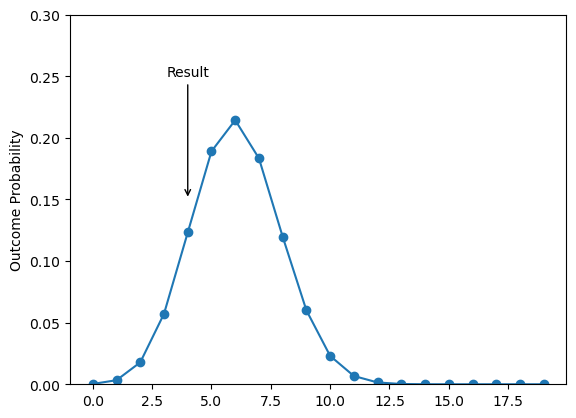

This number of goals would happen in 12.32% of games


In [26]:
all_goals=thorns_goals+royals_goals
x=range(0,20)
outcome_probs=[poisson_binom.pmf(i,test_game['xG'].values)  for i in x]
plt.plot(x,outcome_probs,'o-')
plt.ylabel('Outcome Probability')
plt.annotate('Result',(4,.15),xytext=(4,.25),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.ylim(0,.3)
plt.show()
outcome_percent= round(outcome_probs[int(all_goals)]*100,2)
print(f'This number of goals would happen in {outcome_percent}% of games')

This is good. The outcome is very much within a realistic range of expecte outcomes. So far the model seems to work well. 

## Apply model to a whole World Cup

In [28]:
test_season=pd.read_csv("test_season.csv")
test_season.head()

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id
0,11155,3904629,England Women's,Georgia Stanway,8,28,111.1,30.9,12.728708,0.796509,Right Foot,Half Volley,From Free Kick,0,72,107
1,11156,3904629,England Women's,Georgia Stanway,9,5,113.3,34.1,8.927486,0.721991,Head,Normal,From Corner,0,72,107
2,11157,3904629,England Women's,Alessia Russo,9,7,112.3,37.3,8.159657,0.337253,Head,Normal,From Corner,0,72,107
3,11158,3904629,England Women's,Lauren Hemp,9,13,107.9,29.8,15.825612,0.700402,Left Foot,Volley,From Corner,0,72,107
4,11159,3904629,England Women's,Rachel Daly,12,39,112.0,38.1,8.222530,0.233180,Head,Normal,From Corner,0,72,107


In [29]:
test_season_X = test_season.drop(columns=['is_goal'])

X_test_season_processed = preprocess.transform(test_season_X)

probs = model.predict_proba(X_test_season_processed)[:,1]

test_season['xG'] = probs

display(test_season)

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id,xG
0,11155,3904629,England Women's,Georgia Stanway,8,28,111.1,30.9,12.728708,0.796509,Right Foot,Half Volley,From Free Kick,0,72,107,0.529860
1,11156,3904629,England Women's,Georgia Stanway,9,5,113.3,34.1,8.927486,0.721991,Head,Normal,From Corner,0,72,107,0.537682
2,11157,3904629,England Women's,Alessia Russo,9,7,112.3,37.3,8.159657,0.337253,Head,Normal,From Corner,0,72,107,0.548777
3,11158,3904629,England Women's,Lauren Hemp,9,13,107.9,29.8,15.825612,0.700402,Left Foot,Volley,From Corner,0,72,107,0.440720
4,11159,3904629,England Women's,Rachel Daly,12,39,112.0,38.1,8.222530,0.233180,Head,Normal,From Corner,0,72,107,0.526136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,12830,3893793,Japan Women's,Riko Ueki,78,48,113.3,32.0,10.435037,0.873604,Right Foot,Backheel,From Corner,0,72,107,0.582798
1676,12831,3893793,Japan Women's,Takako Seike,93,50,107.4,23.6,20.681393,0.915690,Right Foot,Normal,Regular Play,0,72,107,0.297370
1677,12832,3893793,Japan Women's,Remina Chiba,94,46,107.4,61.0,24.489998,1.030377,Left Foot,Normal,From Throw In,0,72,107,0.315690
1678,12833,3893793,Japan Women's,Remina Chiba,95,39,112.2,45.5,9.544108,0.614159,Right Foot,Volley,From Corner,0,72,107,0.628402


One out of roughly 56450078177250829425746137355572983300776127510950450606849664325415230549020908157420417861834714813403274751893214444150126709977870618008864499421822108086905946879612025077488992201206588812309736726241485117804031403622400.0 seasons would have 184 goals or fewer.


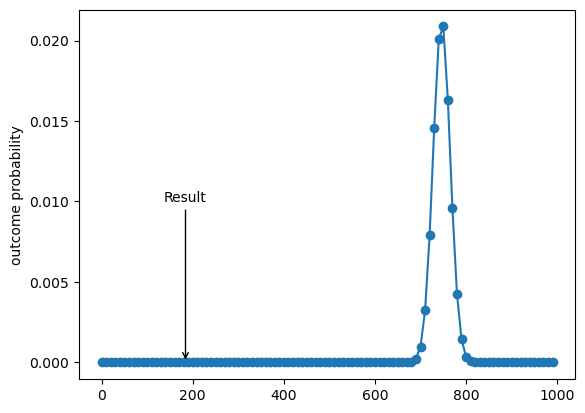

In [30]:
season_goals=test_season['is_goal'].sum()
prob_lt = poisson_binom.cdf(season_goals,test_season['xG'].values,)
print(f"One out of roughly {1/prob_lt:.1f} seasons would have {season_goals} goals or fewer.")

x=list(range(0,1000,10))
plt.plot(x,[poisson_binom.pmf(i,test_season['xG'].values)  for i in x],'o-')
plt.ylabel('outcome probability')
plt.annotate('Result',(season_goals,.0),xytext=(season_goals,.01),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.show()

Ok this means our model is miscalibrated. We are overestimating the amount of expected goals by a very large amount. 

## Retrain Model

The weights need to be updated to reflect the actual percentage of shots that go in. Around 11.3%. The data we currently have has 50% of shots going in. 

In [38]:
pi_real_1 = 0.113
pi_real_0 = 0.887

pi_dataset_1 = y_train.mean()
pi_dataset_0 = 1 - pi_dataset_1

class_weights = {
    0: pi_real_0 / pi_dataset_0,
    1: pi_real_1 / pi_dataset_1
}

print("Class Weights:", class_weights)

model_weighted = RandomForestClassifier(
    **hyper_parameters,
    class_weight=class_weights,
    random_state = 42
)

model_weighted.fit(X_train, y_train)

test_game_X = test_game.drop(columns=['is_goal'])
X_test_game_processed = preprocess.transform(test_game_X)

probs_game_weighted = model_weighted.predict_proba(X_test_game_processed)[:, 1]
test_game['xG_weighted'] = probs_game_weighted



test_season_X = test_season.drop(columns=['is_goal'])
X_test_season_processed = preprocess.transform(test_season_X)

probs_season_weighted = model_weighted.predict_proba(X_test_season_processed)[:, 1]
test_season['xG_weighted'] = probs_season_weighted



print("Average xG (game):", test_game['xG_weighted'].mean())
print("Average xG (season):", test_season['xG_weighted'].mean())


Class Weights: {0: np.float64(1.765433713784021), 1: np.float64(0.22710195035460995)}
Average xG (game): 0.08526858154191402
Average xG (season): 0.12799315481011503


One out of roughly 114.9 seasons would have 184 goals or fewer.


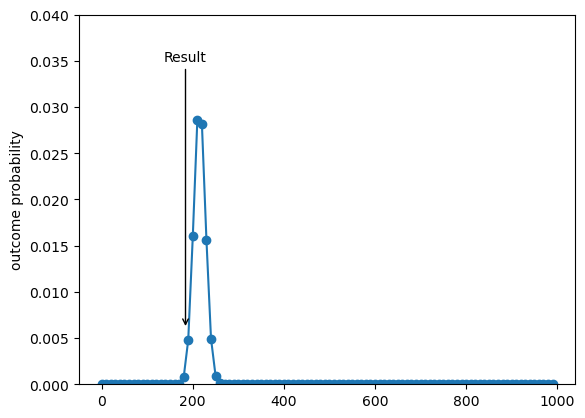

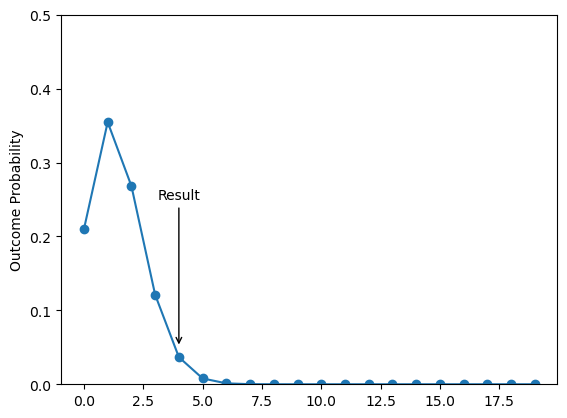

This number of goals would happen in 3.67% of games


In [36]:
prob_lt = poisson_binom.cdf(season_goals,test_season['xG_weighted'].values,)
print(f"One out of roughly {1/prob_lt:.1f} seasons would have {season_goals} goals or fewer.")

x=list(range(0,1000,10))
plt.plot(x,[poisson_binom.pmf(i,test_season['xG_weighted'].values)  for i in x],'o-')
plt.ylabel('outcome probability')
plt.annotate('Result',(season_goals,.006),xytext=(season_goals,.035),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.ylim(0,0.04)
plt.show()

all_goals=thorns_goals+royals_goals
x=range(0,20)
outcome_probs=[poisson_binom.pmf(i,test_game['xG_weighted'].values)  for i in x]
plt.plot(x,outcome_probs,'o-')
plt.ylabel('Outcome Probability')
plt.annotate('Result',(4,.05),xytext=(4,.25),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.ylim(0,.5)
plt.show()
outcome_percent= round(outcome_probs[int(all_goals)]*100,2)
print(f'This number of goals would happen in {outcome_percent}% of games')



## Correct by hand rather than reweighting model

In [39]:
pi_real_1 = 0.113
pi_real_0 = 0.887

pi_dataset_1 = y_train.mean()
pi_dataset_0 = 1 - pi_dataset_1



def prior_correct(p_old, pi_real_1, pi_dataset_1):
    
    numerator = (pi_real_1 / pi_dataset_1) * p_old
    
    denominator = (
        (pi_real_1 / pi_dataset_1) * p_old +
        ((1 - pi_real_1) / (1 - pi_dataset_1)) * (1 - p_old)
    )
    
    return numerator / denominator



test_game['xG_hand_weighted'] = prior_correct(
    test_game['xG'],
    pi_real_1,
    pi_dataset_1
)



test_season['xG_hand_weighted'] = prior_correct(
    test_season['xG'],
    pi_real_1,
    pi_dataset_1
)



print("Old Season Avg xG:", test_season['xG'].mean())
print("Hand Corrected Avg xG:", test_season['xG_hand_weighted'].mean())

Old Season Avg xG: 0.4442824325688436
Hand Corrected Avg xG: 0.11704959743787648


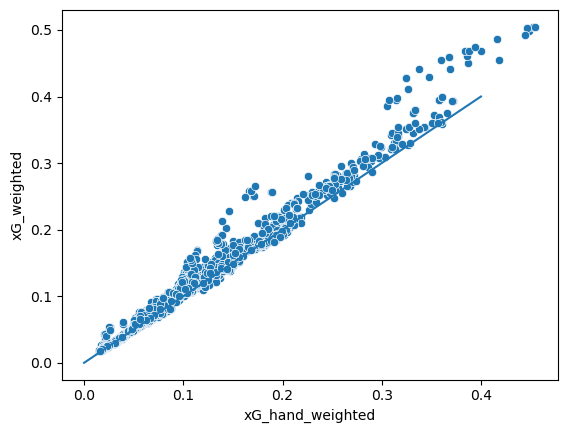

In [40]:
sns.scatterplot(test_season,x='xG_hand_weighted',y='xG_weighted')
plt.plot([0,.4],[0,.4])

## Results Summary
- **Model Performance:** Achieved 69% accuracy with well-calibrated 
  probabilities (ECE < 0.05)
- **Key Finding:** Class weighting was essential - without it, the model 
  overestimated goal probability by 4x
- **Application:** The Poisson-Binomial analysis showed that the 4-goal 
  game result had a X% probability given the shot quality

## Technical Skills Demonstrated
- Handling imbalanced classification data
- Model calibration and probability adjustment
- Feature engineering for spatial data
- Statistical validation of predictions